# Phase 2: Song Version Embeddings + Clustering
Use filename-grouped instances and MERT embeddings to compare versions of a specific song and flag likely bad recordings.

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoModel, Wav2Vec2FeatureExtractor

from pipeline.config import load_config
from pipeline.organize import build_song_version_catalog

In [7]:
summary_path

PosixPath('/home/sylvansky/dev/data/windows_d_drive/music-pipeline/analyzed/song_versions_summary.csv')

In [8]:
config = load_config()
instances_path = config['ANALYZED_DIR'] / 'song_instances.csv'
summary_path = config['ANALYZED_DIR'] / 'song_versions_summary.csv'

if instances_path.exists() and summary_path.exists():
    instances_df = pd.read_csv(instances_path)
    summary_df = pd.read_csv(summary_path)
else:
    instances_df, summary_df = build_song_version_catalog(config['FILES_CSV'], exclude_hidden=True)
    config['ANALYZED_DIR'].mkdir(parents=True, exist_ok=True)
    instances_df.to_csv(instances_path, index=False)
    summary_df.to_csv(summary_path, index=False)

print(f'Loaded {len(instances_df)} instances across {len(summary_df)} song groups')
summary_df.head(20)

Loaded 1453 instances across 113 song groups


,song_key,recordings_count,first_recording_date,last_recording_date,distinct_versions,has_wip,total_duration_seconds,total_duration_hours
0,devil,100,2020-02-29,2025-03-19,2,False,24934.267622,6.926185
1,never,82,2020-02-29,2024-08-21,3,False,25598.523563,7.110701
2,try,77,2020-05-02,2025-03-19,0,False,17831.679365,4.953244
3,insane,69,2020-02-29,2024-04-23,4,False,20502.590456,5.695164
4,play,63,2020-06-13,2025-03-19,0,False,20472.541138,5.686817
5,mirror,62,2020-11-25,2025-03-19,0,False,12832.354804,3.564543
6,wait,62,2020-06-13,2024-04-23,0,False,18883.279501,5.245355
7,bitch,61,2020-02-15,2023-06-07,2,False,16582.376841,4.606216
8,easy,59,2020-02-29,2025-03-19,4,False,16725.302784,4.645917
9,descent,58,2020-02-29,2024-04-23,3,False,17759.696644,4.933249


## Choose Song Key
Pick one canonical `song_key` from the summary table (for example: `song 05`).

In [ ]:
TARGET_SONG_KEY = 'devil'
MIN_DURATION_SECONDS = 45
DISTANCE_THRESHOLD = 0.35
MODEL_NAME = 'm-a-p/MERT-v1-95M'
MODEL_TRUST_REMOTE_CODE = True
MAX_AUDIO_SECONDS = 180
CHUNK_SECONDS = 15

In [9]:
song_df = instances_df[instances_df['song_key'] == TARGET_SONG_KEY].copy()
if song_df.empty:
    raise ValueError(f'No recordings found for song_key={TARGET_SONG_KEY!r}')

song_df['full_path'] = song_df['filepath_anonymized'].apply(lambda p: config['LOCAL_DATA_PATH'] / Path(str(p)))
song_df['exists'] = song_df['full_path'].apply(lambda p: p.exists())
song_df = song_df[song_df['exists']].copy().reset_index(drop=True)

print(f'Recordings found for {TARGET_SONG_KEY}: {len(song_df)}')
song_df[['file_stem', 'recording_date', 'version_num', 'part', 'duration_seconds', 'is_wip', 'full_path']]

Recordings found for devil: 100


,file_stem,recording_date,version_num,part,duration_seconds,is_wip,full_path
0,devil_in_disguise_v1_20200229,2020-02-29,1.0,NaN,328.012313,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
1,devil_in_disguise_v2_20200229,2020-02-29,2.0,NaN,353.803560,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
2,devil_in_disguise_v1_20200307,2020-03-07,1.0,NaN,328.856735,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
3,devil_in_disguise_v2_20200307,2020-03-07,2.0,NaN,341.761859,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
4,devil_in_disguise_202003014_v1,2020-03-14,1.0,NaN,333.322449,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
...,...,...,...,...,...,...,...
95,Devil_in_Disguise_20201104_rosemount,NaN,NaN,NaN,283.895533,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
96,Devil_in_Disguise_20210217,NaN,NaN,NaN,288.222698,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
97,Devil_in_Disguise_20210313,NaN,NaN,NaN,278.866122,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...
98,Devil_in_Disguise_20210321,NaN,NaN,NaN,304.566077,False,/home/sylvansky/dev/data/windows_d_drive/Sonic...


## Load MERT and Extract Embeddings
On RTX 5070 Ti, `m-a-p/MERT-v1-95M` should run on CUDA. If CUDA is not available, this falls back to CPU.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=MODEL_TRUST_REMOTE_CODE,
).to(device).eval()
target_sr = feature_extractor.sampling_rate

print(f'Device: {device}')
print(f'Model: {MODEL_NAME}')
print(f'Target sample rate: {target_sr}')

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

configuration_MERT.py:   0%|          | 0.00/5.34k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_MERT.py:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- modeling_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Device: cuda
Model: m-a-p/MERT-v1-95M
Target sample rate: 24000


In [15]:
def _load_with_ffmpeg_binary(path: Path, target_sr: int) -> torch.Tensor:
    import subprocess
    import imageio_ffmpeg

    ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()
    cmd = [
        ffmpeg_exe,
        '-v', 'error',
        '-i', str(path),
        '-f', 'f32le',
        '-ac', '1',
        '-ar', str(target_sr),
        '-',
    ]
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    if proc.returncode != 0:
        err_lines = proc.stderr.decode('utf-8', errors='ignore').strip().splitlines()
        detail = err_lines[-1] if err_lines else f'ffmpeg decode failed ({proc.returncode})'
        raise RuntimeError(detail)

    audio = np.frombuffer(proc.stdout, dtype=np.float32)
    if audio.size == 0:
        raise RuntimeError('ffmpeg returned empty audio stream')
    return torch.from_numpy(audio.copy())


def load_audio_mono(path: Path, target_sr: int) -> torch.Tensor:
    try:
        waveform, sr = torchaudio.load(str(path))
        if waveform.ndim == 2 and waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, target_sr)
        return waveform.squeeze(0)
    except Exception as exc:
        print(f"torchaudio fallback for {path.name}: {type(exc).__name__}; trying librosa")
        try:
            import librosa
            audio, _ = librosa.load(str(path), sr=target_sr, mono=True)
            return torch.from_numpy(audio).float()
        except Exception as librosa_exc:
            print(f"librosa fallback for {path.name}: {type(librosa_exc).__name__}; trying ffmpeg-binary")
            return _load_with_ffmpeg_binary(path, target_sr)


def embed_file(path: Path) -> np.ndarray:
    audio = load_audio_mono(path, target_sr)
    max_samples = int(MAX_AUDIO_SECONDS * target_sr)
    if audio.numel() > max_samples:
        audio = audio[:max_samples]

    chunk_size = int(CHUNK_SECONDS * target_sr)
    chunks = []
    start = 0
    while start < audio.numel():
        chunk = audio[start:start + chunk_size]
        if chunk.numel() == 0:
            break
        chunks.append(chunk)
        start += chunk_size

    chunk_embeddings = []
    for chunk in chunks:
        inputs = feature_extractor(
            chunk.numpy(),
            sampling_rate=target_sr,
            return_tensors='pt',
        )
        input_values = inputs.input_values.to(device)
        with torch.inference_mode():
            outputs = model(input_values=input_values)
            hidden = outputs.last_hidden_state
            emb = hidden.mean(dim=1).squeeze(0).detach().cpu().numpy()
        chunk_embeddings.append(emb)

    return np.mean(np.stack(chunk_embeddings, axis=0), axis=0)


embeddings = []
for _, row in song_df.iterrows():
    try:
        embeddings.append(embed_file(row['full_path']))
    except Exception as exc:
        print(f"Failed embedding for {row['file_stem']}: {type(exc).__name__}: {exc}")
        embeddings.append(None)

song_df['embedding_ok'] = [e is not None for e in embeddings]
valid_df = song_df[song_df['embedding_ok']].copy().reset_index(drop=True)
valid_embeddings = [e for e in embeddings if e is not None]

print(f'Embeddings successful: {len(valid_embeddings)} / {len(song_df)}')

torchaudio fallback for devil_in_disguise_v1_20200229.mp3: RuntimeError; trying librosa
torchaudio fallback for devil_in_disguise_v2_20200229.mp3: RuntimeError; trying librosa
torchaudio fallback for devil_in_disguise_v1_20200307.mp3: RuntimeError; trying librosa
librosa fallback for devil_in_disguise_v1_20200307.mp3: NoBackendError; trying ffmpeg-binary


/tmp/ipykernel_35326/2086202194.py:39: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(path), sr=target_sr, mono=True)
/home/sylvansky/dev/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


torchaudio fallback for devil_in_disguise_v2_20200307.mp3: RuntimeError; trying librosa
librosa fallback for devil_in_disguise_v2_20200307.mp3: NoBackendError; trying ffmpeg-binary
torchaudio fallback for devil_in_disguise_202003014_v1.mp3: RuntimeError; trying librosa
librosa fallback for devil_in_disguise_202003014_v1.mp3: NoBackendError; trying ffmpeg-binary
torchaudio fallback for Devil_in_Disguise_20200502.mp3: RuntimeError; trying librosa
librosa fallback for Devil_in_Disguise_20200502.mp3: NoBackendError; trying ffmpeg-binary
torchaudio fallback for Devil_in_Disguise_20200502a.mp3: RuntimeError; trying librosa
librosa fallback for Devil_in_Disguise_20200502a.mp3: NoBackendError; trying ffmpeg-binary
torchaudio fallback for Devil_in_Disguise_20200516.mp3: RuntimeError; trying librosa
librosa fallback for Devil_in_Disguise_20200516.mp3: NoBackendError; trying ffmpeg-binary
torchaudio fallback for Devil_in_Disguise_20200523.mp3: RuntimeError; trying librosa
librosa fallback for Dev

## Cluster Versions and Flag Bad Recording Candidates

In [16]:
if len(valid_embeddings) < 2:
    valid_df['cluster_id'] = 0
    valid_df['outlier_score'] = 0.0
else:
    X = np.stack(valid_embeddings, axis=0)

    try:
        clusterer = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=DISTANCE_THRESHOLD,
            metric='cosine',
            linkage='average',
        )
    except TypeError:
        clusterer = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=DISTANCE_THRESHOLD,
            affinity='cosine',
            linkage='average',
        )

    labels = clusterer.fit_predict(X)
    valid_df['cluster_id'] = labels

    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / np.clip(norms, 1e-8, None)
    outlier_scores = np.zeros(len(valid_df), dtype=float)

    for cid in sorted(valid_df['cluster_id'].unique()):
        idx = np.where(valid_df['cluster_id'].values == cid)[0]
        cluster_vecs = Xn[idx]
        centroid = cluster_vecs.mean(axis=0, keepdims=True)
        centroid /= np.clip(np.linalg.norm(centroid, axis=1, keepdims=True), 1e-8, None)
        sims = (cluster_vecs @ centroid.T).squeeze(1)
        dists = 1 - sims
        if len(dists) > 1:
            z = (dists - dists.mean()) / (dists.std() + 1e-8)
            outlier_scores[idx] = z
        else:
            outlier_scores[idx] = 0.0

    valid_df['outlier_score'] = outlier_scores

valid_df['duration_seconds'] = pd.to_numeric(valid_df['duration_seconds'], errors='coerce')
valid_df['bad_candidate'] = (
    (valid_df['duration_seconds'].fillna(0) < MIN_DURATION_SECONDS)
    | (valid_df['outlier_score'] >= 1.0)
)

sim_matrix = cosine_similarity(np.stack(valid_embeddings, axis=0)) if len(valid_embeddings) > 1 else None

view_cols = [
    'file_stem', 'recording_date', 'version_num', 'part', 'duration_seconds',
    'cluster_id', 'outlier_score', 'is_wip', 'bad_candidate', 'filepath_anonymized'
]
valid_df.sort_values(['bad_candidate', 'outlier_score', 'recording_date'], ascending=[False, False, True])[view_cols]

,file_stem,recording_date,version_num,part,duration_seconds,cluster_id,outlier_score,is_wip,bad_candidate,filepath_anonymized
76,devil(2)_20240815,2024-08-14,NaN,NaN,NaN,0,3.548225,False,True,Sonica/audio/rehearsal archive/20240814/devil(...
2,devil_in_disguise_v1_20200307,2020-03-07,1.0,NaN,328.856735,0,3.318526,False,True,Sonica/audio/rehearsal archive/20200307/devil_...
81,devil_20241023,2024-10-23,NaN,NaN,NaN,0,3.116404,False,True,Sonica/audio/rehearsal archive/20241023/devil_...
69,devil_20240417,2024-04-17,NaN,NaN,312.428050,0,2.225439,False,True,Sonica/audio/rehearsal archive/20240417/devil_...
83,devil_20241128,2024-11-28,NaN,NaN,NaN,0,2.119107,False,True,Sonica/audio/rehearsal archive/20241128/devil_...
...,...,...,...,...,...,...,...,...,...,...
59,Devil_20230315,2023-03-15,NaN,NaN,315.288163,0,-1.082369,False,False,Sonica/audio/rehearsal archive/20230315/Devil_...
37,Devil_in_Disguise_20210526,2021-05-26,NaN,NaN,328.346825,0,-1.099137,False,False,Sonica/audio/rehearsal archive/20210526/Devil_...
31,Devil_in_Disguise_20210308,2021-03-08,NaN,NaN,289.795578,0,-1.149201,False,False,Sonica/audio/rehearsal archive/20210308/Devil_...
20,Devil_in_Disguise_20201017,2020-10-17,NaN,NaN,307.532313,0,-1.341697,False,False,Sonica/audio/rehearsal archive/20201017/Devil_...


In [17]:
safe_song = re.sub(r'[^a-zA-Z0-9]+', '_', TARGET_SONG_KEY).strip('_').lower()
clusters_path = config['ANALYZED_DIR'] / f'song_version_clusters_{safe_song}.csv'
valid_df.to_csv(clusters_path, index=False)
print(f'Saved clustering output: {clusters_path}')

if sim_matrix is not None:
    sim_df = pd.DataFrame(sim_matrix, index=valid_df['file_stem'], columns=valid_df['file_stem'])
    sim_path = config['ANALYZED_DIR'] / f'song_similarity_{safe_song}.csv'
    sim_df.to_csv(sim_path)
    print(f'Saved similarity matrix: {sim_path}')

valid_df['bad_candidate'].value_counts()

Saved clustering output: /home/sylvansky/dev/data/windows_d_drive/music-pipeline/analyzed/song_version_clusters_devil.csv
Saved similarity matrix: /home/sylvansky/dev/data/windows_d_drive/music-pipeline/analyzed/song_similarity_devil.csv


bad_candidate
False    73
True     27
Name: count, dtype: int64

## Cluster Visualization
Simple view of cluster sizes and average outlier score per cluster.

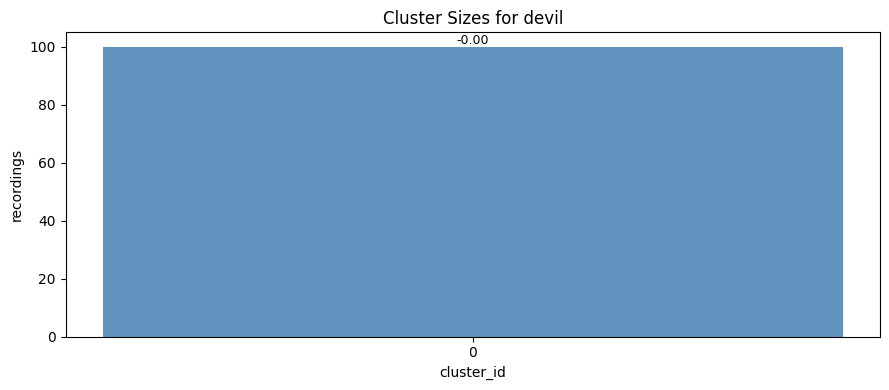

In [19]:
import matplotlib.pyplot as plt

if valid_df.empty:
    print('No valid embeddings to visualize.')
else:
    cluster_stats = (
        valid_df.groupby('cluster_id', dropna=False)
        .agg(recordings=('file_stem', 'count'), avg_outlier=('outlier_score', 'mean'))
        .reset_index()
        .sort_values('recordings', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    x = cluster_stats['cluster_id'].astype(str)
    bars = ax.bar(x, cluster_stats['recordings'], color='steelblue', alpha=0.85)
    ax.set_title(f'Cluster Sizes for {TARGET_SONG_KEY}')
    ax.set_xlabel('cluster_id')
    ax.set_ylabel('recordings')

    for bar, avg_outlier in zip(bars, cluster_stats['avg_outlier']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{avg_outlier:.2f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    cluster_stats